Generate data and save it so later can be analyzed

In [1]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import twistaly as tw

parent_dir = "data/"
file_dir = "data100ns-2008"
output_dir = "output-100ns2008"

u_mean = md.Universe(parent_dir + file_dir + "/md_1.tpr", parent_dir + output_dir + "/md_1_mean.xtc")

`u_mean` already contains the whole information of the mean positions, then one can do manipulation with it more quickly. The only thing is that the routine of centering has to be changed inside. Then we can get the whole fragments list and use it for the next steps.

In [2]:
chains = u_mean.select_atoms("protein").fragments

In [35]:
# Atom Group to Analyze
group = "all"

# Parameters of Analysis
tot_mol = int((len(chains))/3)
tau = np.zeros(tot_mol)
r2s = np.zeros(tot_mol)
mean_rad = np.zeros(tot_mol)
std_rad = np.zeros(tot_mol)
length = np.zeros(tot_mol)
res_vars = np.zeros(tot_mol)
molecules = np.arange(0, tot_mol)

# Analysis Part -- MOST IMPORTANT --
for mol in range(tot_mol):
    molecule = chains[3*mol:3*mol + 3]
    molecule_coords = (molecule[0].select_atoms(group) + molecule[1].select_atoms(group) + molecule[2].select_atoms(group)).positions

    # Length of the Molecule
    length[mol] = (molecule_coords[:,2].max() - molecule_coords[:,2].min()) / 10

    # Apply Filter
    molecule_mean_filt = tw.remove_ends(0.5, molecule_coords) / 10

    # Cylindrical Coordinates
    rad, phi, z = tw.cyl_proj(molecule_mean_filt)
    arc = rad*phi

    # Orth Fit
    tau[mol], _, res_vars[mol] = tw.ortreglinfit(z, arc)

    # Radius Data
    mean_rad[mol] = np.mean(rad)
    std_rad[mol] = np.std(rad)

psi = np.atan(tau)

In [36]:
# For plotting
eval_fit = np.linspace(0, max(mean_rad) + 0.5, 1000)

# Filters
filt_r2 = 0.05
filt_length = 60
filt_sep = 0.6

# Psi - Deg
psi = np.rad2deg(psi)

# Weight test
weights = 1 / std_rad

# Filter data
maskr2 = (r2s >= filt_r2)
tau_filt = tau[maskr2]
psi_filt = psi[maskr2]
mean_rad_filt = mean_rad[maskr2]
std_rad_filt = std_rad[maskr2]
length_filt = length[maskr2]

# Filter for length
masklgth = (length >= filt_length)
psi_lgth = psi[masklgth]
mean_rad_lgth = mean_rad[masklgth]
std_rad_lgth = std_rad[masklgth]
r2s_lgth = r2s[masklgth]
weights_lgth = weights[masklgth]

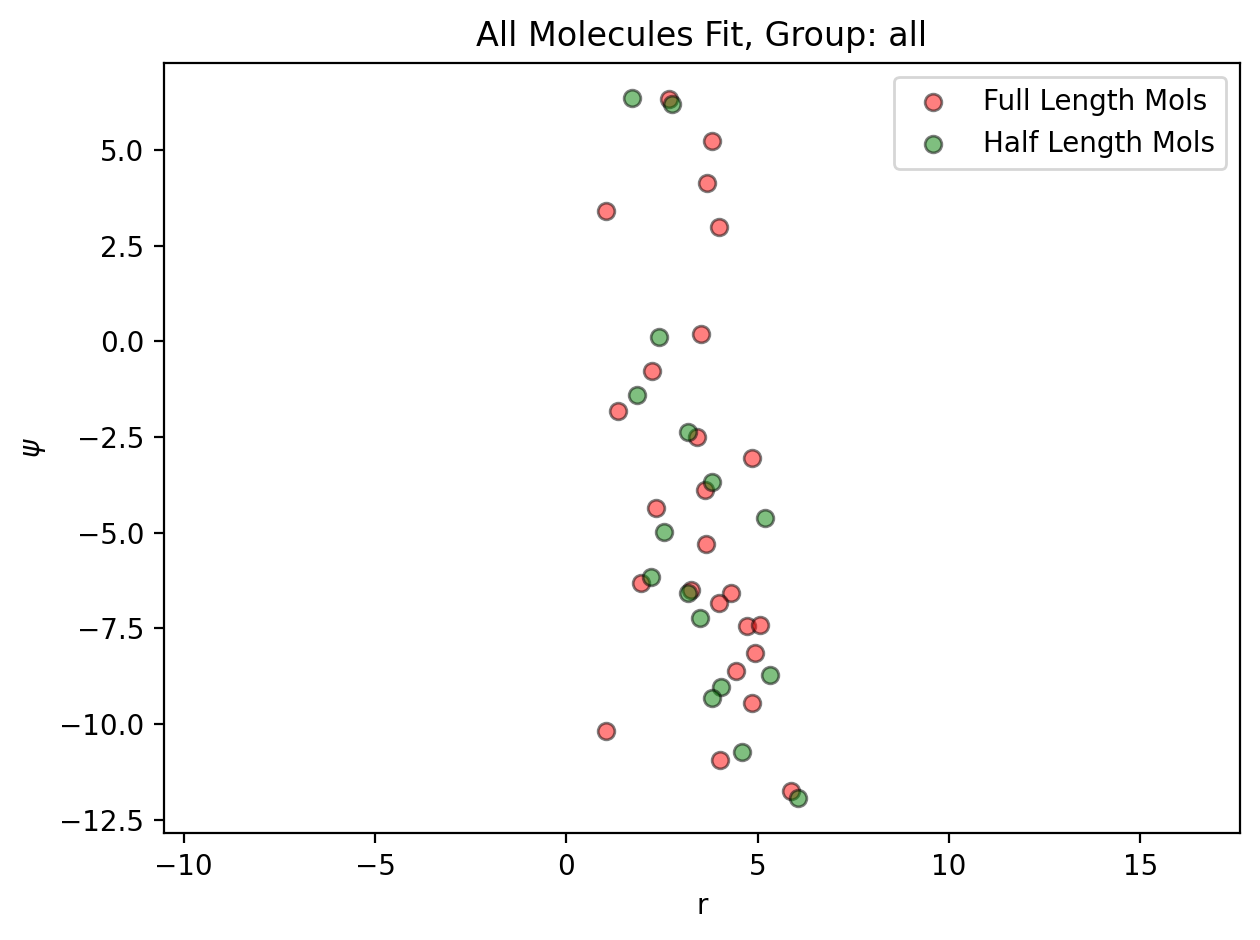

In [37]:
plt.figure(dpi=200)
mean_rad_fl, psi_fl = mean_rad[masklgth], psi[masklgth]
mean_rad_hl, psi_hl = mean_rad[~masklgth], psi[~masklgth]

plt.scatter(mean_rad_fl, psi_fl, color='r', edgecolor='k', alpha=0.5, label=r'Full Length Mols')
plt.scatter(mean_rad_hl, psi_hl, color='g', edgecolor='k', alpha=0.5, label=r'Half Length Mols')

plt.title(f"All Molecules Fit, Group: {group}")
plt.ylabel(r"$\psi$")
plt.xlabel("r")

plt.tight_layout()
plt.axis("equal")
plt.legend()
plt.show()